### This script does basic bhv quantifications
#### this script runs DLC and quantifies the gazes
#### this script focuses on the summarizing results pooling all six (five in reality, kanga is shared) animals (three dyads); it can only be run after the "BasicBhvAna_singlecam_wholebodylabels_allsessions_basicEvents_PullStartToPull_section_continuousBhv_PCAonBhv"

In [3]:
import pandas as pd
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import seaborn
import scipy
import scipy.stats as st
import scipy.io
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import string
import warnings
import pickle
import json

from scipy.ndimage import gaussian_filter1d

import os
import glob
import random
from time import time

from scipy.ndimage import label


### function - get body part location for each pair of cameras

In [4]:
from ana_functions.body_part_locs_eachpair import body_part_locs_eachpair
from ana_functions.body_part_locs_singlecam import body_part_locs_singlecam

### function - align the two cameras

In [5]:
from ana_functions.camera_align import camera_align       

### function - merge the two pairs of cameras

In [6]:
from ana_functions.camera_merge import camera_merge

### function - find social gaze time point

In [7]:
from ana_functions.find_socialgaze_timepoint import find_socialgaze_timepoint
from ana_functions.find_socialgaze_timepoint_singlecam import find_socialgaze_timepoint_singlecam
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody import find_socialgaze_timepoint_singlecam_wholebody
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody_2 import find_socialgaze_timepoint_singlecam_wholebody_2

### function - define time point of behavioral events

In [8]:
from ana_functions.bhv_events_timepoint import bhv_events_timepoint
from ana_functions.bhv_events_timepoint_singlecam import bhv_events_timepoint_singlecam

### function - plot behavioral events

In [9]:
from ana_functions.plot_bhv_events import plot_bhv_events
from ana_functions.plot_bhv_events_levertube import plot_bhv_events_levertube
from ana_functions.plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection import plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection
from ana_functions.plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace import plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace

from ana_functions.draw_self_loop import draw_self_loop
import matplotlib.patches as mpatches 
from matplotlib.collections import PatchCollection

### function - plot inter-pull interval

In [10]:
from ana_functions.plot_interpull_interval import plot_interpull_interval

### function - make demo videos with skeleton and inportant vectors

In [11]:
from ana_functions.tracking_video_singlecam_demo import tracking_video_singlecam_demo
from ana_functions.tracking_video_singlecam_wholebody_demo import tracking_video_singlecam_wholebody_demo

### function - interval between all behavioral events

In [12]:
from ana_functions.bhv_events_interval import bhv_events_interval

### function - other useful functions

In [13]:
# get useful information about pulls
from ana_functions.get_pull_infos import get_pull_infos

In [14]:
# for projecting high D bhv variables to small PC space
from ana_functions.singlecam_conBhv_from_highDimension_to_PCspace import get_data_for_singlecam_conBhv_from_highDimension_to_PCspace

In [15]:
# use the gaze vector speed and face mass speed to find the pull action start time within IPI
from ana_functions.find_sharp_increases_withinIPI import find_sharp_increases_withinIPI
from ana_functions.find_sharp_increases_withinIPI import find_sharp_increases_withinIPI_dual_speed

In [16]:
# method 2: find the lowest timepoint then the increase point as the pull onset
from ana_functions.find_rising_onset_after_min_withinIPI import find_rising_onset_after_min_withinIPI
from ana_functions.find_rising_onset_after_min_withinIPI import find_rising_onset_after_min_dual_speed

## Analyze each session

### prepare the basic behavioral data (especially the time stamps for each bhv events)
### separate each session based on trial types (different force levels)

In [17]:
# instead of using gaze angle threshold, use the target rectagon to deside gaze info
# ...need to update
sqr_thres_tubelever = 75 # draw the square around tube and lever
sqr_thres_face = 1.15 # a ratio for defining face boundary
sqr_thres_body = 4 # how many times to enlongate the face box boundry to the body


# get the fps of the analyzed video
fps = 30

# frame number of the demo video
# nframes = 0.5*30 # second*30fps
nframes = 1*30 # second*30fps

# re-analyze the video or not
reanalyze_video = 0
redo_anystep = 0

# only analyze the best (five) sessions for each conditions
do_bestsession = 1
if do_bestsession:
    savefile_sufix = '_bestsessions'
else:
    savefile_sufix = '_allsessions'
    
    
# if use onset of the first increase after min
doOnsetAfterMin = 1
if not doOnsetAfterMin:
    doOnsetAfterMin_suffix = 'bhvPCA_'
elif doOnsetAfterMin:
    doOnsetAfterMin_suffix = 'bhvPCA_PullOnsetAfterMin_'

# if use a hmm based method to find the trial start
doHMMmethod = 0
if doHMMmethod:
    doOnsetAfterMin_suffix = 'HMMmethods_'
    
    

# force manipulation type
# SR_bothchange: self reward, both forces changed
# CO_bothchange: 1s cooperation, both forces changed
# CO_A1change: 1s cooperation, animal 1 forces changed
# CO_A2change: 1s cooperation, animal 2 forces changed
forceManiTypes = ['SR_bothchange','CO_A1change','CO_A2change']
nforceManiTypes = np.shape(forceManiTypes)[0]

#  
animal1_fixedorders = ['koala', 'dannon', 'dodson']
animal2_fixedorders = ['vermelho', 'kanga', 'kanga' ]

animal1_filenames = ["Koala","Dannon","Dodson"]
animal2_filenames = ["Vermelho","Kanga","Kanga"]

nanimalpairs = np.shape(animal1_fixedorders)[0]


# video tracking results info
animalnames_videotrack = ['dodson','scorch'] # does not really mean dodson and scorch, instead, indicate animal1 and animal2
bodypartnames_videotrack = ['rightTuft','whiteBlaze','leftTuft','rightEye','leftEye','mouth']


# which camera to analyzed
cameraID = 'camera-2'
cameraID_short = 'cam2'


# location of levers and tubes for camera 2
# get this information using DLC animal tracking GUI, the results are stored: 
# /home/ws523/marmoset_tracking_DLCv2/marmoset_tracking_with_lever_tube-weikang-2023-04-13/labeled-data/
considerlevertube = 1
considertubeonly = 0
# # camera 1
# lever_locs_camI = {'dodson':np.array([645,600]),'scorch':np.array([425,435])}
# tube_locs_camI  = {'dodson':np.array([1350,630]),'scorch':np.array([555,345])}
# # camera 2
lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
tube_locs_camI  = {'dodson':np.array([1550,515]),'scorch':np.array([350,515])}
# # lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
# # tube_locs_camI  = {'dodson':np.array([1650,490]),'scorch':np.array([250,490])}
# # camera 3
# lever_locs_camI = {'dodson':np.array([1580,440]),'scorch':np.array([1296,540])}
# tube_locs_camI  = {'dodson':np.array([1470,375]),'scorch':np.array([805,475])}


# where to save the summarizing data
data_saved_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_analysis_forceManipulation_task_data_saved/'


    

In [18]:
# =========================================================
# BUILD COMBINED PULL-LEVEL DATAFRAME FOR ALL ANIMALS
# =========================================================

rows = []

for ianimalpair in range(nanimalpairs):

    animal1 = animal1_fixedorders[ianimalpair]
    animal2 = animal2_fixedorders[ianimalpair]

    for iforceManiType in range(nforceManiTypes):

        forceManiType = forceManiTypes[iforceManiType]

        data_saved_subfolder = (
            data_saved_folder
            + 'data_saved_singlecam_wholebody'
            + savefile_sufix + '/'
            + cameraID + '/'
            + animal1 + animal2 + '/'
        )

        # ---------------- LOAD ----------------
        with open(data_saved_subfolder + f'/pullstartTopull_trig_events_all_dates_{doOnsetAfterMin_suffix}{animal1}{animal2}_{forceManiType}.pkl', 'rb') as f:
            pullstartTopull_trig_events_all_dates = pickle.load(f)

        with open(data_saved_subfolder + f'/pull_rts_all_dates_{doOnsetAfterMin_suffix}{animal1}{animal2}_{forceManiType}.pkl', 'rb') as f:
            pull_rts_all_dates = pickle.load(f)

        with open(data_saved_subfolder + f'/pull_infos_all_dates_{animal1}{animal2}_{forceManiType}.pkl', 'rb') as f:
            pull_infos_all_dates = pickle.load(f)

        print('loaded:', animal1, animal2, forceManiType)

        # ---------------- FORCE CONDITION LABELS ----------------
        if forceManiType == 'SR_bothchange':
            forceType_A1 = 'self_change_SR'
            forceType_A2 = 'self_change_SR'

        elif forceManiType == 'CO_A1change':
            forceType_A1 = 'self_change_MC'
            forceType_A2 = 'partner_change_MC'

        elif forceManiType == 'CO_A2change':
            forceType_A1 = 'partner_change_MC'
            forceType_A2 = 'self_change_MC'

        else:
            forceType_A1 = None
            forceType_A2 = None

        # ---------------- LOOP DATES ----------------
        for date in pull_rts_all_dates.keys():

            animals = list(pull_rts_all_dates[date].keys())

            for self_animal in animals:

                partner_animal = [a for a in animals if a != self_animal][0]

                # rename kanga when paired with dodson (your convention)
                self_name = self_animal
                partner_name = partner_animal

                if self_name == 'kanga' and partner_name == 'dodson':
                    self_name = 'kanga_withDo'
                if partner_name == 'kanga' and self_name == 'dodson':
                    partner_name = 'kanga_withDo'

                # pick correct force condition label
                if self_animal == animal1:
                    forceContType = forceType_A1
                else:
                    forceContType = forceType_A2

                pull_rts = pull_rts_all_dates[date][self_animal]
                info = pull_infos_all_dates[date]
                trig = pullstartTopull_trig_events_all_dates[date]

                failpull = info[(self_animal, 'num_preceding_failpull')].reset_index(drop=True)
                t_last_rew = info[(self_animal, 'time_from_last_reward')].reset_index(drop=True)
                pull_interval = info[(self_animal, 'pull_interval')].reset_index(drop=True)
                self_force = pd.to_numeric(info[(self_animal, 'lever_force')], errors='coerce').reset_index(drop=True)
                partner_force = pd.to_numeric(info[(self_animal, 'partner_lever_force')], errors='coerce').reset_index(drop=True)

                self_gaze_trace = trig[(self_animal, 'socialgaze_prob')]
                partner_PC1_trace = trig[(self_animal, 'other_PC1')]
                
                self_LS_trace = trig[(self_animal, 'mass_move_speed')]

                for pull_id in range(len(pull_rts)):

                    gaze_trace = self_gaze_trace[pull_id]
                    pc1_trace = partner_PC1_trace[pull_id]
                    LS_trace = self_LS_trace[pull_id]

                    gaze_accum = float(np.nansum(gaze_trace))
                    
                    self_LS_mean = float(np.nanmean(LS_trace))
                    self_LS_std = float(np.nanstd(LS_trace))

                    mask = gaze_trace > 0.05
                    pc1_mean = float(np.nanmean(pc1_trace[mask])) if np.any(mask) else np.nan
                    pc1_std = float(np.nanstd(pc1_trace[mask])) if np.any(mask) else np.nan
                    
                    
                                      

                    rows.append({
                        'date': date,
                        'forceContType': forceContType,

                        'self_animal': self_name,
                        'partner_animal': partner_name,
                        'pair': animal1 + animal2,

                        'pull_id': pull_id,
                        'pull_rt': pull_rts[pull_id],

                        'self_force': self_force.iloc[pull_id],
                        'partner_force': partner_force.iloc[pull_id],

                        'num_preceding_failpull': failpull.iloc[pull_id],
                        'time_from_last_reward': t_last_rew.iloc[pull_id],
                        'pull_interval': pull_interval.iloc[pull_id],

                        'gaze_accum': gaze_accum,
                        'partner_PC1_mean': pc1_mean,
                        'partner_PC1_std': pc1_std,
                        
                        'self_LS_mean': self_LS_mean,
                        'self_LS_std': self_LS_std,
                    })

# =========================================================
# CREATE DATAFRAME
# =========================================================
big_pull_df_all = pd.DataFrame(rows)

# =========================================================
# SORT
# =========================================================
big_pull_df_all = big_pull_df_all.sort_values(
    ['date', 'self_animal', 'pull_id']
)

# =========================================================
# SUBBLOCK ID
# =========================================================
big_pull_df_all['force_pair'] = list(
    zip(big_pull_df_all['self_force'], big_pull_df_all['partner_force'])
)

big_pull_df_all['subblockID'] = (
    big_pull_df_all
    .groupby(['date', 'self_animal'])['force_pair']
    .transform(lambda s: (s != s.shift()).cumsum() - 1)
)

big_pull_df_all = big_pull_df_all.drop(columns='force_pair')

# =========================================================
# DELTA FORCE (BLOCK LEVEL)
# =========================================================
for (date, animal), df in big_pull_df_all.groupby(['date', 'self_animal']):

    df = df.sort_values('pull_id')

    block_force = (
        df.groupby('subblockID')[['self_force','partner_force']]
        .first()
        .sort_index()
    )

    delta_first = block_force - block_force.iloc[0]
    delta_prev = block_force.diff().fillna(0)

    big_pull_df_all.loc[df.index, 'delta_self_force_first'] = df['subblockID'].map(delta_first['self_force'])
    big_pull_df_all.loc[df.index, 'delta_self_force_prev']  = df['subblockID'].map(delta_prev['self_force'])

    big_pull_df_all.loc[df.index, 'delta_partner_force_first'] = df['subblockID'].map(delta_first['partner_force'])
    big_pull_df_all.loc[df.index, 'delta_partner_force_prev']  = df['subblockID'].map(delta_prev['partner_force'])
    

loaded: koala vermelho SR_bothchange
loaded: koala vermelho CO_A1change
loaded: koala vermelho CO_A2change
loaded: dannon kanga SR_bothchange
loaded: dannon kanga CO_A1change
loaded: dannon kanga CO_A2change
loaded: dodson kanga SR_bothchange
loaded: dodson kanga CO_A1change
loaded: dodson kanga CO_A2change


In [19]:
# save the data "big_pull_df_all" for other analysis
with open('big_pull_df_all.pkl', 'wb') as f:
    pickle.dump(big_pull_df_all, f)
    
big_pull_df_all['delta_partner_self_force'] = (big_pull_df_all['partner_force']-big_pull_df_all['self_force'])

big_pull_df_all['norm_delta_partner_self_force'] = (big_pull_df_all['partner_force']-big_pull_df_all['self_force'])/\
                    (big_pull_df_all['partner_force']+big_pull_df_all['self_force'])

big_pull_df_all


,date,forceContType,self_animal,partner_animal,pair,pull_id,pull_rt,self_force,partner_force,num_preceding_failpull,...,partner_PC1_std,self_LS_mean,self_LS_std,subblockID,delta_self_force_first,delta_self_force_prev,delta_partner_force_first,delta_partner_force_prev,delta_partner_self_force,norm_delta_partner_self_force
0,20240228,self_change_SR,koala,vermelho,koalavermelho,0,2.100000,480.000031,480.000031,0,...,0.105073,269.344293,233.539305,0,0.0,0.0,0.0,0.0,0.0,0.0
1,20240228,self_change_SR,koala,vermelho,koalavermelho,1,7.900000,480.000031,480.000031,0,...,1.181687,209.927648,192.140356,0,0.0,0.0,0.0,0.0,0.0,0.0
2,20240228,self_change_SR,koala,vermelho,koalavermelho,2,4.733333,480.000031,480.000031,0,...,NaN,121.405717,154.910387,0,0.0,0.0,0.0,0.0,0.0,0.0
3,20240228,self_change_SR,koala,vermelho,koalavermelho,3,1.966667,480.000031,480.000031,0,...,NaN,245.487925,236.202491,0,0.0,0.0,0.0,0.0,0.0,0.0
4,20240228,self_change_SR,koala,vermelho,koalavermelho,4,8.800000,480.000031,480.000031,0,...,1.494714,184.021767,170.968784,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6049,20250523_SR,self_change_SR,kanga_withDo,dodson,dodsonkanga,14,7.433333,150.000000,150.000000,0,...,0.156329,55.454482,34.578538,1,-50.0,-50.0,-50.0,-50.0,0.0,0.0
6050,20250523_SR,self_change_SR,kanga_withDo,dodson,dodsonkanga,15,7.100000,150.000000,150.000000,0,...,NaN,36.007522,51.770204,1,-50.0,-50.0,-50.0,-50.0,0.0,0.0
6051,20250523_SR,self_change_SR,kanga_withDo,dodson,dodsonkanga,16,7.200000,150.000000,150.000000,0,...,NaN,11.873891,11.793423,1,-50.0,-50.0,-50.0,-50.0,0.0,0.0
6052,20250523_SR,self_change_SR,kanga_withDo,dodson,dodsonkanga,17,3.700000,385.000000,385.000000,0,...,NaN,36.931500,21.740199,2,185.0,235.0,185.0,235.0,0.0,0.0


/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:170: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:187: RuntimeWarning: divide by zero encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:194: RuntimeWarning: invalid value encountered in double_scalars
  intercept_stderr = slope_stderr * np.sqrt(ssxm + xmean**2)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:170: RuntimeWarning: invalid value encountered in double_scalars
  slope = ssxym / ssxm
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/scipy/stats/_stats_mstats_common.py:187: RuntimeWarning: divide by zero encountered in double_scalars
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm 

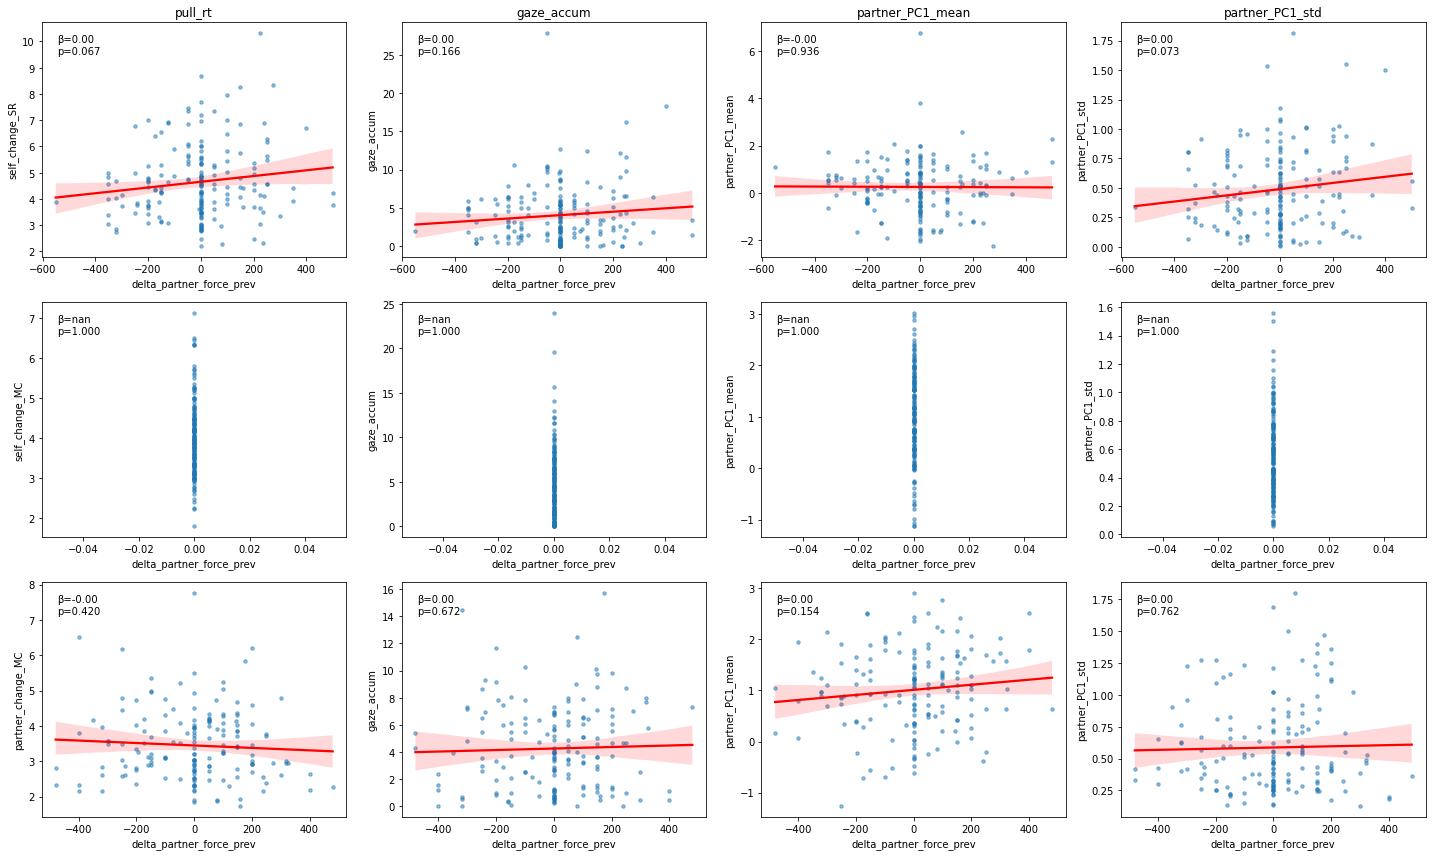

In [74]:
# ============================================
# SETTINGS
# ============================================

import seaborn as sns
import statsmodels.formula.api as smf


x_var = 'delta_partner_force_prev'
# choose from:
# 'self_force','partner_force',
# 'delta_self_force_first','delta_self_force_prev',
# 'delta_partner_force_first','delta_partner_force_prev'
# 'delta_partner_self_force'
# 'norm_delta_partner_self_force'

y_vars = [
    'pull_rt',
    'gaze_accum',
    'partner_PC1_mean',
    'partner_PC1_std'
]

force_order = [
    'self_change_SR',
    'self_change_MC',
    'partner_change_MC'
]

# ============================================
# DATA PREP
# ============================================

plot_df = big_pull_df_all.copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)

# optional RT outlier removal
def iqr_filter(group):
    q1 = group['pull_rt'].quantile(0.25)
    q3 = group['pull_rt'].quantile(0.75)
    iqr = q3 - q1
    return group[(group['pull_rt'] >= q1 - 1.5*iqr) &
                 (group['pull_rt'] <= q3 + 1.5*iqr)]

plot_df = (
    plot_df
    .groupby(['self_animal','date'], group_keys=False)
    .apply(iqr_filter)
    .reset_index(drop=True)
)

plot_df['self_animal'] = plot_df['self_animal'].astype('category')

# OPTIONAL: log RT for stability
# plot_df['pull_rt'] = np.log(plot_df['pull_rt'])

# ============================================
# FIGURE
# ============================================

n_rows = len(force_order)
n_cols = len(y_vars)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5*n_cols, 4*n_rows),
                         sharex=False, sharey=False)

for i, force_type in enumerate(force_order):

    df_force = plot_df[plot_df['forceContType'] == force_type]

    for j, y in enumerate(y_vars):

        ax = axes[i, j]

        data = df_force[[x_var, y, 'date', 'self_animal', 'subblockID']].dropna()
        # data = df_force[[x_var, y, 'date', 'subblockID']].dropna()
        
        # average across trial in each subblock
        if 1:
            data = (
                    data
                    .groupby(['date', 'self_animal', 'subblockID'])[[x_var, y]]
                    .mean(numeric_only=True)
                    .reset_index()
                    )
            data = data.dropna()

        if len(data) < 10:
            ax.set_title(f"{force_type}\nnot enough data")
            continue

        # ---------------- SCATTER ----------------
        sns.regplot(
            data=data,
            x=x_var,
            y=y,
            ax=ax,
            scatter_kws={'s': 12, 'alpha': 0.5},
            line_kws={'color': 'red'}
        )


        # ---------------- LMM ----------------
        if 0:
            data_lmm = data.rename(columns={x_var: 'x', y: 'y'})

            # use_block = data_lmm['subblockID'].nunique() > 1
            # formula = "y ~ x" + (" + subblockID" if use_block else "")
            formula = "y ~ x"

            try:
                model = smf.mixedlm(
                    formula,
                    data_lmm,
                    # groups=data_lmm["self_animal"]
                    groups=data_lmm["date"]
                )

                fit = model.fit(method='lbfgs', disp=False)

                beta = fit.params['x']
                pval = fit.pvalues['x']

            except:
                beta, pval = np.nan, np.nan
                
        # ---------------- REGRESSION ----------------
        if 1:
            from scipy import stats
            data_reg = data[[x_var, y]].dropna().rename(columns={x_var: 'x', y: 'y'})
            try:
                slope, intercept, r, pval, se = stats.linregress(data_reg['x'], data_reg['y'])
                beta = slope
            except:
                beta, pval = np.nan, np.nan

        ax.text(0.05, 0.95,
                f"β={beta:.2f}\np={pval:.3f}",
                transform=ax.transAxes,
                va='top')

        # ---------------- LABELS ----------------
        if i == 0:
            ax.set_title(y)

        if j == 0:
            ax.set_ylabel(force_type)

        if i == n_rows - 1:
            ax.set_xlabel(x_var)

plt.tight_layout()
# plt.show()

# ================= SAVE =================
savefigs = 1

if savefigs:

    figsavefolder = (
        data_saved_folder +
        'figs_for_BasicBhvAna_singlecam_wholebodylabels_allsessions_basicEvents_PullStartToPull_section_continuousBhv_PCAonBhv_allanimal_summary/' +
        savefile_sufix + '/' + cameraID + '/'
    )

    os.makedirs(figsavefolder, exist_ok=True)

    fig.savefig(
        figsavefolder +
        x_var +
        "level_vs_DDMvariables_allanimal_allcondition.pdf"
    )


In [61]:
# ================================
# AIC/BIC comparison — SELF FORCE ONLY
# pooled across animals
# no random effects
# control for subblockID
# ================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# --------------------------------
# SETTINGS
# --------------------------------

y_vars = [
    'pull_rt',
    'gaze_accum',
    'partner_PC1_mean',
    'partner_PC1_std'
]

force_models = {
    'raw'        : 'self_force',
    'delta_first': 'delta_self_force_first',
    'delta_prev' : 'delta_self_force_prev',
}

block_var = 'subblockID'

# --------------------------------
# CLEAN DATA
# --------------------------------

df = big_pull_df_all.copy()
df = df.replace([np.inf, -np.inf], np.nan)

results = []

# --------------------------------
# LOOP
# --------------------------------

for y in y_vars:

    for model_name, x in force_models.items():

        cols = [y, x, block_var]
        data = df[cols].dropna()

        if len(data) < 20:
            continue

        # ---------- baseline (block only) ----------
        try:
            model0 = smf.ols(
                f"{y} ~ {block_var}",
                data=data
            ).fit()
        except:
            continue

        # ---------- force + block ----------
        try:
            model1 = smf.ols(
                f"{y} ~ {x} + {block_var}",
                data=data
            ).fit()
        except:
            continue

        results.append({
            'yvar': y,
            'force_model': model_name,
            'n': len(data),

            'AIC_block_only': model0.aic,
            'AIC_force+block': model1.aic,
            'ΔAIC_force': model1.aic - model0.aic,

            'BIC_block_only': model0.bic,
            'BIC_force+block': model1.bic,
            'ΔBIC_force': model1.bic - model0.bic
        })

# --------------------------------
# RESULTS TABLE
# --------------------------------

results_df = (
    pd.DataFrame(results)
    .sort_values(['yvar', 'ΔAIC_force'])
)

display(results_df)

# --------------------------------
# BEST MODEL PER VARIABLE
# --------------------------------

best_models = results_df.loc[
    results_df.groupby('yvar')['ΔAIC_force'].idxmin()
]

print("\n🏆 Best self-force model per variable (by AIC):")
display(best_models)

,yvar,force_model,n,AIC_block_only,AIC_force+block,ΔAIC_force,BIC_block_only,BIC_force+block,ΔBIC_force
5,gaze_accum,delta_prev,7147,51017.212038,50986.303436,-30.908602,51030.960934,51006.926780,-24.034154
4,gaze_accum,delta_first,7147,51017.212038,50994.832838,-22.379200,51030.960934,51015.456182,-15.504752
3,gaze_accum,raw,7147,51017.212038,50995.934778,-21.277259,51030.960934,51016.558122,-14.402812
6,partner_PC1_mean,raw,5095,18078.714547,18071.185809,-7.528738,18091.786577,18090.793854,-0.992723
7,partner_PC1_mean,delta_first,5095,18078.714547,18080.039529,1.324982,18091.786577,18099.647574,7.860997
8,partner_PC1_mean,delta_prev,5095,18078.714547,18080.684820,1.970273,18091.786577,18100.292865,8.506288
9,partner_PC1_std,raw,5095,8150.091700,8119.388534,-30.703166,8163.163730,8138.996579,-24.167152
10,partner_PC1_std,delta_first,5095,8150.091700,8123.811537,-26.280163,8163.163730,8143.419582,-19.744148
11,partner_PC1_std,delta_prev,5095,8150.091700,8127.100467,-22.991233,8163.163730,8146.708512,-16.455218
0,pull_rt,raw,7147,48699.250455,48634.742521,-64.507934,48712.999351,48655.365865,-57.633486



🏆 Best self-force model per variable (by AIC):


,yvar,force_model,n,AIC_block_only,AIC_force+block,ΔAIC_force,BIC_block_only,BIC_force+block,ΔBIC_force
5,gaze_accum,delta_prev,7147,51017.212038,50986.303436,-30.908602,51030.960934,51006.926780,-24.034154
6,partner_PC1_mean,raw,5095,18078.714547,18071.185809,-7.528738,18091.786577,18090.793854,-0.992723
9,partner_PC1_std,raw,5095,8150.091700,8119.388534,-30.703166,8163.163730,8138.996579,-24.167152
0,pull_rt,raw,7147,48699.250455,48634.742521,-64.507934,48712.999351,48655.365865,-57.633486
